# Data Exploration and Feature Engineering

Explore PFR training data and define inputs (`df_features`) and outputs (`df_target`) for ML. Run cells in order.


## 1. Setup

Import libraries and set plot style. 


In [ ]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import datetime


def rows_at_inlet_plane(df: pd.DataFrame) -> pd.DataFrame:
    """Rows at inlet plane: minimum relative_position (fallback: minimum z_position_m)."""
    if df is None or len(df) == 0:
        return df
    if 'relative_position' in df.columns:
        rp_min = df['relative_position'].min()
        return df.loc[(df['relative_position'] - rp_min).abs() < 1e-12].copy()
    if 'z_position_m' in df.columns:
        z_min = df['z_position_m'].min()
        return df.loc[(df['z_position_m'] - z_min).abs() < 1e-12].copy()
    return df.copy()


def rows_at_exit_plane(df: pd.DataFrame) -> pd.DataFrame:
    """Rows at exit plane: maximum relative_position (fallback: maximum z_position_m)."""
    if df is None or len(df) == 0:
        return df
    if 'relative_position' in df.columns:
        rp_max = df['relative_position'].max()
        return df.loc[(df['relative_position'] - rp_max).abs() < 1e-12].copy()
    if 'z_position_m' in df.columns:
        z_max = df['z_position_m'].max()
        return df.loc[(df['z_position_m'] - z_max).abs() < 1e-12].copy()
    return df.copy()


# Project root resolution (notebook lives in notebooks/)
_cwd = Path(os.getcwd())
project_root = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.utils.plot_style import setup_matplotlib
from src.utils.run_log import start_run_log
from src.ml.dataframe_pickle import load_dataframe_pickle, save_pickle_portable
from src.utils.plot_parallel import plot_parallel_coordinates, plot_parallel_sets

setup_matplotlib()
start_run_log('Main_3_data_exploration_feature_engineering')

print("Libraries imported successfully.")

Config. Edit `configs/ml/main3_eda_feature_engineering_config.json` to change these (edit and re-run this cell; no kernel restart needed). After the setup cell, all paths use `project_root` (repo root). Toggle `IF_LOAD_DATA`, `PRINT_ON_SCREEN`, `IF_EXPORT_FEATURES_TARGETS`, and `IF_SAVE_EDA_PLOTS`. With `IF_PIN_SPECIFIC_FILES`, load pinned files under `data/training/` (e.g. `*_20260507_DEVEL.*` = small smoke-test set); `False` uses the newest files there.

In [ ]:
# ── Load config (edit configs/ml/main3_eda_feature_engineering_config.json) ──
CONFIG_PATH = project_root / "configs" / "ml" / "main3_eda_feature_engineering_config.json"
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        _cfg = json.load(f)
else:
    _cfg = {}
    print(f"[WARN] Config not found: {CONFIG_PATH}. Using defaults.")

PRINT_ON_SCREEN = _cfg.get("print_on_screen", True)
IF_LOAD_DATA    = _cfg.get("if_load_data", True)
IF_SAVE_EDA_PLOTS = _cfg.get("if_save_eda_plots", True)
EDA_FIG_DIR = project_root / "outputs" / "figures" / "Main_3_data_exploration_feature_engineering" / "eda"

# ── Velocity QC (applied in §2.1b) ────────────────────────────────────────
IF_VELOCITY_QC = _cfg.get("if_velocity_qc", False)              # set False to skip (not recommended)
VELOCITY_QC_QUANTILE = _cfg.get("velocity_qc_quantile", 0.995)  # upper bound on peak velocity per run

#___ Species lumping for dimensionality reduction (150+ species → grouped features)
# These flags group species into categories for downstream ML feature engineering.
# Instead of predicting individual species, predict lumped yields (sum of Y_ within each group).
# By carbon number: C1, C2, C3, ... + inert (useful for yield distribution analysis)
IF_SEPARATE_SPECIES_BY_CARBON = _cfg.get("if_separate_species_by_carbon", True)

IF_CATEGORIZE_BY_CHEMISTRY = _cfg.get("if_categorize_by_chemistry", True)
# By chemistry/process role: olefins, aromatics, paraffins, coke_precursors, radicals, feedstock, hydrogen, diluent
# Export df_target: keep all Y_* columns or replace with lump sums (smaller ML pickle for Main_4).
# Mass fractions (Y_*) only — mole fractions (X_*) are not exported as ML targets.
# 'lumped_chemistry' needs IF_CATEGORIZE_BY_CHEMISTRY. 'lumped_carbon' needs IF_SEPARATE_SPECIES_BY_CARBON.
EXPORT_SPECIES_AS = _cfg.get("export_species_as", "lumped_chemistry")  # 'individual' | 'lumped_chemistry' | 'lumped_carbon'
#___

# Reaction rate proxies (§3c, for Main_8 SR) -- requires lumped_chemistry target export
IF_COMPUTE_RATES = _cfg.get("if_compute_rates", True)

# After setup cell: cwd is project_root — use repo paths (not ../data/... which leaves the project).
BASE_DIR_ALL = str(project_root / "data" / "training")
EXPORT_DIR   = str(project_root / "data" / "processed")


# __Latest in data/training/, or pin a run stamp (DEVEL = small smoke-test set):
IF_PIN_SPECIFIC_FILES = _cfg.get("if_pin_specific_files", True)
RUN_STAMP_DEVEL = _cfg.get("run_stamp_devel", "20260507_DEVEL")   # small campaign (same data as 20260507_111316)
RUN_STAMP_FULL  = _cfg.get("run_stamp_full", "20260507_095243")  # full campaign

RUN_STAMP = RUN_STAMP_FULL if _cfg.get("use_run_stamp", "full") == "full" else RUN_STAMP_DEVEL

PIN_CORE_DATA_FILE = f"training_data_complete_{RUN_STAMP}.pkl"
PIN_META_DATA_FILE = f"metadata_{RUN_STAMP}.json"
# DEVEL files: training_data_complete_20260507_DEVEL.pkl + metadata_20260507_DEVEL.json

_data_files = sorted(Path(BASE_DIR_ALL).glob("training_data_complete_*.pkl"), reverse=True)
_meta_files = sorted(Path(BASE_DIR_ALL).glob("metadata_*.json"), reverse=True)

if IF_PIN_SPECIFIC_FILES:
    CORE_DATA_FILE_NAME = PIN_CORE_DATA_FILE
    META_DATA_FILE_NAME = PIN_META_DATA_FILE
else:
    CORE_DATA_FILE_NAME = _data_files[0].name if _data_files else ""
    META_DATA_FILE_NAME = _meta_files[0].name if _meta_files else ""

# __ IF EXPORT FEATURES
IF_EXPORT_FEATURES_TARGETS      = _cfg.get("if_export_features_targets", False)
EXPORT_FEATURES_TARGETS_FILE_NAME = f"features_targets_{CORE_DATA_FILE_NAME.replace('.pkl', '')}.pkl"
# __

print(50*"=")
print('USER IO FLAGS:')
print(f'LOAD_DATA = {IF_LOAD_DATA}')
print(f'DATA SOURCE = {"pinned " + RUN_STAMP if IF_PIN_SPECIFIC_FILES else "latest in data/training"}')
print(f'CORE DATA FILE NAME = {CORE_DATA_FILE_NAME}')
print(f'META DATA FILE NAME = {META_DATA_FILE_NAME}')
print(f'BASE DIR ALL = {BASE_DIR_ALL}')
print(f'IF_SAVE_EDA_PLOTS = {IF_SAVE_EDA_PLOTS}')
print(f'EDA_FIG_DIR = {EDA_FIG_DIR}')
print(f'IF_VELOCITY_QC = {IF_VELOCITY_QC} (quantile={VELOCITY_QC_QUANTILE})')
print(f'IF_SEPARATE_SPECIES_BY_CARBON = {IF_SEPARATE_SPECIES_BY_CARBON}')
print(f'IF_CATEGORIZE_BY_CHEMISTRY = {IF_CATEGORIZE_BY_CHEMISTRY}')
print(f'EXPORT_SPECIES_AS = {EXPORT_SPECIES_AS}')
print(f'IF_COMPUTE_RATES = {IF_COMPUTE_RATES}')
print(f'IF_EXPORT_FEATURES_TARGETS = {IF_EXPORT_FEATURES_TARGETS}')
print(f'EXPORT_DIR = {EXPORT_DIR}')
print(f'EXPORT_FEATURES_TARGETS_FILE_NAME = {EXPORT_FEATURES_TARGETS_FILE_NAME}')
print(50*"=")


## 2. Load training data

Loads from paths above; populates `df_data` and optional `df_meta`.


In [ ]:
# Paths: BASE_DIR_ALL is under project_root (see config cell). Uses os.path.join for Windows/Linux.
df_data = pd.DataFrame()
df_meta = {}

if IF_LOAD_DATA:
    print(50*"=")
    FILE_PATH_DATA = os.path.join(BASE_DIR_ALL, CORE_DATA_FILE_NAME)
    FILE_PATH_META = os.path.join(BASE_DIR_ALL, META_DATA_FILE_NAME)
    if os.path.isfile(FILE_PATH_DATA):
        df_data = load_dataframe_pickle(FILE_PATH_DATA)
        n_before = len(df_data)
        df_data = df_data.dropna()
        n_dropped = n_before - len(df_data)
        if n_dropped > 0:
            print(f'Dropped {n_dropped} rows with NaN ({n_before} -> {len(df_data)}).')
        if os.path.isfile(FILE_PATH_META):
            with open(FILE_PATH_META, 'r') as f:
                df_meta = json.load(f)
        print(f'Data loaded :\n{CORE_DATA_FILE_NAME}, \n{META_DATA_FILE_NAME}')
    else:
        print(f'File not found: {FILE_PATH_DATA}')

print(50*"=")

### 2.1 Data overview

Shape, unique `reactant_type`, and column list. Gated by PRINT_ON_SCREEN.


In [ ]:
# Data exploration (only when we have data)
if len(df_data) == 0:
    print("No data loaded. Skip exploration or load data in the previous cell.")
elif PRINT_ON_SCREEN:
    print(50*"=")
    print("Dataframe shape:", df_data.shape[0], "rows and", df_data.shape[1], "columns")
    print(50*"")
    if 'reactant_type' in df_data.columns:
        print('Unique reactant types:', df_data['reactant_type'].unique())
    print(50*"")
    print("Dataframe columns:", df_data.columns.to_list())
    print(50*"=")
else:
    print("Data exploration output skipped (PRINT_ON_SCREEN=False).")

### 2.1b Velocity QC

Filter simulation runs with non-physical velocity (u ≤ 0 or non-finite) or extreme outliers
(above the 99.5th percentile of peak velocity per run). A single bad axial point removes the
entire run so that ML training rows are always physically consistent.

In [ ]:
# ── Velocity QC ──────────────────────────────────────────────

BC_COLS = [
    'initial_temperature_K', 'initial_pressure_Pa',
    'reactor_length_m', 'reactor_diameter_m',
    'mass_flow_rate_kgps', 'heat_flux_Wm2',
]

def _velocity_qc(df, vel_col='velocity_ms', bc_cols=BC_COLS, quantile=0.995):
    """Remove runs with non-physical or extreme velocity."""
    import numpy as np
    present_bc = [c for c in bc_cols if c in df.columns]
    if vel_col not in df.columns:
        print('[velocity QC] velocity_ms not found — skipping.')
        return df, {}

    bad_rows = ~np.isfinite(df[vel_col]) | (df[vel_col] <= 0)
    n0 = len(df)

    # Identify bad runs (any row with bad velocity contaminates the whole run)
    if present_bc:
        bad_keys = df[bad_rows][present_bc].drop_duplicates()
        mask_bad = df[present_bc].merge(
            bad_keys, on=present_bc, how='left', indicator=True
        )['_merge'].values == 'both'
    else:
        mask_bad = bad_rows.values

    df_clean = df[~mask_bad]

    # Remove extreme velocity outliers (peak u per run above quantile)
    if present_bc and vel_col in df_clean.columns:
        run_max_vel = df_clean.groupby(present_bc)[vel_col].transform('max')
        u_thresh = df_clean[vel_col].quantile(quantile)
        mask_extreme = run_max_vel > u_thresh
        df_clean = df_clean[~mask_extreme]
    else:
        u_thresh = float('inf')
        mask_extreme = pd.Series(False, index=df_clean.index)

    n_removed = n0 - len(df_clean)
    qc_meta = {
        'n_rows_before': n0,
        'n_rows_after':  len(df_clean),
        'n_removed':     int(n_removed),
        'vel_upper_quantile': float(u_thresh),
        'quantile_level': quantile,
    }
    return df_clean, qc_meta

qc_meta = {}
if len(df_data) > 0 and IF_VELOCITY_QC:
    df_data, qc_meta = _velocity_qc(df_data, quantile=VELOCITY_QC_QUANTILE)
    print(f'Velocity QC: {qc_meta["n_rows_before"]:,} → {qc_meta["n_rows_after"]:,} rows '
          f'({qc_meta["n_removed"]:,} removed, u_max threshold = {qc_meta["vel_upper_quantile"]:.2f} m/s)')
else:
    print('Velocity QC skipped.')

### 2.2 Input feature distributions

Histograms of the 6 swept operating parameters — confirms the sampling coverage (LHS / grid / random).

In [ ]:
if len(df_data) > 0:
    df_eda = rows_at_inlet_plane(df_data)
    sweep_params = [
        ('initial_temperature_K',  'Inlet T (K)'),
        ('initial_pressure_Pa',    'Inlet P (bar)'),
        ('reactor_length_m',       'Length (m)'),
        ('reactor_diameter_m',     'Diameter (m)'),
        ('mass_flow_rate_kgps',    'Mass flow (kg/s)'),
        ('heat_flux_Wm2',          'Heat flux (kW/m²)'),
    ]
    sweep_params = [(c, l) for c, l in sweep_params if c in df_data.columns]

    if sweep_params:
        n_cols = min(3, len(sweep_params))
        n_rows = (len(sweep_params) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(4.5 * n_cols, 3.0 * n_rows),
            squeeze=False,
        )
        setup_matplotlib(axes)
        for ax, (col, label) in zip(axes.ravel(), sweep_params):
            values = df_eda[col]
            if col == 'initial_pressure_Pa':
                values = values / 1e5  # Pa -> bar
            elif col == 'heat_flux_Wm2':
                values = values / 1e3  # W/m^2 -> kW/m^2

            # Normalized histogram (probability density): total area = 1
            ax.hist(
                values,
                bins=40,
                density=True,
                color='steelblue',
                edgecolor='white',
                linewidth=0.4,
                alpha=0.85,
            )
            ax.set_xlabel(label, fontsize=9)
            ax.set_ylabel('Probability density')
            ax.set_title(label, fontsize=9)
        for ax in axes.ravel()[len(sweep_params) :]:
            ax.set_visible(False)
        fig.suptitle('Input parameter probability distributions (inlet plane, one row per run)', y=1.04)
        plt.tight_layout()
        if IF_SAVE_EDA_PLOTS:
            EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)
            fig.savefig(EDA_FIG_DIR / 'main3_input_distributions_inlet.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)

### 2.3 Training-space 2D coverage

Pairwise scatter plots for key parameter pairs at the inlet plane, to inspect space-filling quality of generated data.

In [ ]:
if len(df_data) > 0:
    df_eda = rows_at_inlet_plane(df_data).copy()

    # Build display-friendly columns (same spirit as Main_2 preview)
    if 'initial_pressure_Pa' in df_eda.columns and 'pressure_bar' not in df_eda.columns:
        df_eda['pressure_bar'] = df_eda['initial_pressure_Pa'] / 1e5
    if 'reactor_diameter_m' in df_eda.columns and 'diameter_mm' not in df_eda.columns:
        df_eda['diameter_mm'] = df_eda['reactor_diameter_m'] * 1000.0
    if 'heat_flux_Wm2' in df_eda.columns and 'heat_flux_kWm2' not in df_eda.columns:
        df_eda['heat_flux_kWm2'] = df_eda['heat_flux_Wm2'] / 1e3

    pairs = [
        ('initial_temperature_K', 'pressure_bar'),
        ('reactor_length_m', 'diameter_mm'),
        ('mass_flow_rate_kgps', 'heat_flux_kWm2'),
        ('initial_temperature_K', 'reactor_length_m'),
        ('pressure_bar', 'heat_flux_kWm2'),
        ('diameter_mm', 'mass_flow_rate_kgps'),
    ]
    pairs = [(x, y) for x, y in pairs if x in df_eda.columns and y in df_eda.columns]

    if pairs:
        n_cols = min(3, len(pairs))
        n_rows = (len(pairs) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows), squeeze=False)
        setup_matplotlib(axes)

        pretty = {
            'initial_temperature_K': 'Inlet T (K)',
            'pressure_bar': 'Inlet P (bar)',
            'reactor_length_m': 'Length (m)',
            'diameter_mm': 'Diameter (mm)',
            'mass_flow_rate_kgps': 'Mass flow (kg/s)',
            'heat_flux_kWm2': 'Heat flux (kW/m²)',
        }

        for ax, (x, y) in zip(axes.ravel(), pairs):
            ax.scatter(df_eda[x], df_eda[y], alpha=0.05, s=14, c='b')
            ax.set_xlabel(pretty.get(x, x), fontsize=9)
            ax.set_ylabel(pretty.get(y, y), fontsize=9)
            ax.set_title(f"{pretty.get(x, x)} vs {pretty.get(y, y)}", fontsize=9)

        for ax in axes.ravel()[len(pairs):]:
            ax.set_visible(False)

        fig.suptitle('Training space: 2D coverage (inlet plane)', y=1.02)
        plt.tight_layout()
        if IF_SAVE_EDA_PLOTS:
            EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)
            fig.savefig(EDA_FIG_DIR / 'main3_training_space_2d_coverage_inlet.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)

### 2.4 Key output target statistics & distributions

Summary statistics for primary targets and key product species.

In [ ]:
if len(df_data) > 0:
    df_exit = rows_at_exit_plane(df_data)
    primary_output_cols = [
        'temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3',
        'mean_molecular_weight_kgkmol',
        'heat_capacity_cp_JkgK', 'heat_capacity_cv_JkgK',
        'enthalpy_Jkg',
    ]
    primary_output_cols = [c for c in primary_output_cols if c in df_data.columns]

    # ── Derived primary outputs at exit plane ─────────────────────────────────
    run_cols = [c for c in (
        'reactant_type', 'initial_temperature_K', 'initial_pressure_Pa',
        'reactor_length_m', 'reactor_diameter_m', 'mass_flow_rate_kgps', 'heat_flux_Wm2',
    ) if c in df_data.columns]

    # Residence time per run: tau = ∫ dz / u(z)
    # Use a column subset before groupby — grouping the full df (100s of species cols) is very slow
    # and can spike memory while pandas builds splitters / sorted views.
    if run_cols and 'z_position_m' in df_data.columns and 'velocity_ms' in df_data.columns:
        tau_rows = []
        _tau_use = run_cols + ['z_position_m', 'velocity_ms']
        df_tau_src = df_data[_tau_use]
        # NumPy 2.0+ renamed trapz -> trapezoid; keep a fallback for NumPy 1.x.
        _trapz_like = getattr(np, 'trapezoid', np.trapz)
        for _, g in df_tau_src.groupby(run_cols, sort=False):
            g2 = g[['z_position_m', 'velocity_ms']].dropna().sort_values('z_position_m')
            if len(g2) >= 2 and (g2['velocity_ms'] > 0).all():
                tau_s = float(
                    _trapz_like(1.0 / g2['velocity_ms'].to_numpy(), g2['z_position_m'].to_numpy())
                )
                tau_ms = 1e3 * tau_s
            else:
                tau_ms = np.nan
            row = {k: g.iloc[0][k] for k in run_cols}
            row['residence_time_ms'] = tau_ms
            tau_rows.append(row)
        if tau_rows:
            df_tau = pd.DataFrame(tau_rows)
            df_exit = df_exit.merge(df_tau, on=run_cols, how='left')
            primary_output_cols.append('residence_time_ms')

    # n-hexane conversion per run: (Y_in - Y_out) / Y_in * 100
    y_nhex_candidates = [c for c in df_data.columns if c.startswith('Y_') and 'C6H14' in c]
    if run_cols and y_nhex_candidates:
        y_nhex = y_nhex_candidates[0]
        df_inlet = rows_at_inlet_plane(df_data)
        if y_nhex in df_inlet.columns and y_nhex in df_exit.columns:
            c_in = df_inlet[run_cols + [y_nhex]].rename(columns={y_nhex: 'Y_nhex_in'})
            c_out = df_exit[run_cols + [y_nhex]].rename(columns={y_nhex: 'Y_nhex_out'})
            conv = c_out.merge(c_in, on=run_cols, how='left')
            conv['nhexane_conversion_pct'] = np.where(
                conv['Y_nhex_in'] > 0,
                100.0 * (conv['Y_nhex_in'] - conv['Y_nhex_out']) / conv['Y_nhex_in'],
                np.nan,
            )
            df_exit = df_exit.merge(conv[run_cols + ['nhexane_conversion_pct']], on=run_cols, how='left')
            primary_output_cols.append('nhexane_conversion_pct')

    # Lumped C2H* and C3H* production at exit (same panel as residence time)
    y_cols = [c for c in df_data.columns if c.startswith('Y_')]
    c2_cols = [c for c in y_cols if c.startswith('Y_C2H')]
    c3_cols = [c for c in y_cols if c.startswith('Y_C3H')]
    if c2_cols:
        df_exit['c2h_lumped_exit_y'] = df_exit[c2_cols].sum(axis=1)
        primary_output_cols.append('c2h_lumped_exit_y')
    if c3_cols:
        df_exit['c3h_lumped_exit_y'] = df_exit[c3_cols].sum(axis=1)
        primary_output_cols.append('c3h_lumped_exit_y')

    # Keep only columns that exist after derived-feature merges
    primary_output_cols = [c for c in primary_output_cols if c in df_exit.columns]

    if primary_output_cols:
        # ── Descriptive statistics table ─────────────────────────────────────────
        print("Primary target statistics (exit plane):")
        display_df = df_exit[primary_output_cols].copy()
        if 'pressure_Pa' in display_df.columns:
            display_df['pressure_Pa'] = display_df['pressure_Pa'] / 1e5  # Pa -> bar
            display_df = display_df.rename(columns={'pressure_Pa': 'pressure_bar'})

        display_stats = display_df.describe().T[['mean', 'std', 'min', '50%', 'max']]
        display_stats.columns = ['mean', 'std', 'min', 'median', 'max']
        print(display_stats.to_string())

        # ── Distribution plots for primary targets ────────────────────────────────
        n_cols = min(3, len(primary_output_cols))
        n_rows = (len(primary_output_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5 * n_cols, 3.0 * n_rows),
            squeeze=False,
        )
        setup_matplotlib(axes)
        for ax, col in zip(axes.ravel(), primary_output_cols):
            values = df_exit[col]
            label = col
            if col == 'pressure_Pa':
                values = values / 1e5  # Pa -> bar
                label = 'pressure_bar'
            elif col == 'nhexane_conversion_pct':
                label = 'nhexane_conversion_pct (%)'
            elif col == 'residence_time_ms':
                label = 'residence_time_ms'
            elif col == 'c2h_lumped_exit_y':
                label = 'c2h_lumped_exit_y'
            elif col == 'c3h_lumped_exit_y':
                label = 'c3h_lumped_exit_y'

            ax.hist(values, bins=50, color='coral', edgecolor='white', linewidth=0.4, alpha=0.85)
            ax.set_xlabel(label, fontsize=9)
            ax.set_ylabel('Count')
            ax.set_title(label, fontsize=9)
        for ax in axes.ravel()[len(primary_output_cols) :]:
            ax.set_visible(False)
        fig.suptitle('Primary output distributions (exit plane)', y=1.04)
        plt.tight_layout()
        if IF_SAVE_EDA_PLOTS:
            EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)
            fig.savefig(EDA_FIG_DIR / 'main3_primary_output_distributions_exit.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)

    # ── Top species by mean mass fraction (reactor exit) ─────────────────────
    y_cols = [c for c in df_data.columns if c.startswith('Y_')]
    if y_cols:
        mean_yf = df_exit[y_cols].mean().sort_values(ascending=False)
        top_species = mean_yf.head(12)
        fig, ax = plt.subplots(figsize=(10, 4))
        setup_matplotlib(ax)
        ax.bar(range(len(top_species)), top_species.values, color='lightblue', edgecolor='white', linewidth=0.4)
        ax.set_xticks(range(len(top_species)))
        ax.set_xticklabels([c.replace('Y_', '') for c in top_species.index], rotation=90, ha='center', fontsize=8)
        ax.set_ylabel('Mean mass fraction')
        ax.set_title('Top 12 species by mean mass fraction at exit (Y_*)')
        plt.tight_layout()
        if IF_SAVE_EDA_PLOTS:
            EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)
            fig.savefig(EDA_FIG_DIR / 'main3_top12_species_exit_mean_mass_fraction.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"\nTop 12 species at exit (mean Y): {top_species.to_dict()}")

        if 'c2h_lumped_exit_y' in df_exit.columns:
            print(f"C2H* lumped production at exit (mean Y): {float(df_exit['c2h_lumped_exit_y'].mean()):.6e}")
        if 'c3h_lumped_exit_y' in df_exit.columns:
            print(f"C3H* lumped production at exit (mean Y): {float(df_exit['c3h_lumped_exit_y'].mean()):.6e}")

### 2.5 Parallel coordinates & parallel sets (DOE coverage)

Two complementary multi-axis views of the inlet design space. Each operates on one row per PFR run (inlet-plane rows, deduplicated on `run_cols`), joined with `df_exit` to attach `nhexane_conversion_pct`.

- Parallel coordinates (Inselberg), stratified by inlet-T quartile  — one polyline per PFR run across all six inlet variables. The stratification answers within each temperature regime, are the other inlet variables independently sampled, or do they correlate with T?". To keep the plot readable for dense designs, a stratified subsample of ~200 runs is drawn (the title states the displayed-vs-total count).
- Parallel sets (Kosara) — each axis is binned into 5 equal-width categories; ribbon width is proportional to the joint count between adjacent operating regimes, ribbon color is the mean n-hexane conversion in that joint bin. Reveals which regime combinations dominate the training set and which ones convert well or poorly.

In [ ]:
_run_cols = globals().get("run_cols") or []
if len(df_data) > 0 and _run_cols:

    # One row per PFR run (inlet plane rows are constant across z within a run,
    # but we drop_duplicates on run_cols to be safe in case of repeats).
    df_design = rows_at_inlet_plane(df_data)[_run_cols].drop_duplicates().copy()

    # Display-friendly columns (mirrors section 2.4 conventions).
    if 'initial_pressure_Pa' in df_design.columns:
        df_design['pressure_bar'] = df_design['initial_pressure_Pa'] / 1e5
    if 'reactor_diameter_m' in df_design.columns:
        df_design['diameter_mm'] = df_design['reactor_diameter_m'] * 1000.0
    if 'heat_flux_Wm2' in df_design.columns:
        df_design['heat_flux_kWm2'] = df_design['heat_flux_Wm2'] / 1e3

    # Attach conversion from df_exit (computed in section 2.4 above).
    _df_exit = globals().get("df_exit")
    if _df_exit is not None and 'nhexane_conversion_pct' in _df_exit.columns:
        df_design = df_design.merge(
            _df_exit[_run_cols + ['nhexane_conversion_pct']].drop_duplicates(subset=_run_cols),
            on=_run_cols, how='left',
        )

    design_dims = [c for c in (
        'initial_temperature_K', 'pressure_bar',
        'reactor_length_m', 'diameter_mm',
        'mass_flow_rate_kgps', 'heat_flux_kWm2',
    ) if c in df_design.columns]

    pretty = {
        'initial_temperature_K': 'Inlet T (K)',
        'pressure_bar': 'Inlet P (bar)',
        'reactor_length_m': 'Length (m)',
        'diameter_mm': 'Diameter (mm)',
        'mass_flow_rate_kgps': 'Mass flow (kg/s)',
        'heat_flux_kWm2': 'Heat flux (kW/m²)',
    }
    axis_labels = [pretty.get(c, c) for c in design_dims]

    if len(design_dims) >= 2:
        color_col = ('nhexane_conversion_pct'
                     if 'nhexane_conversion_pct' in df_design.columns else None)
        n_runs = len(df_design)
        print(f"Parallel plots: {n_runs} unique design points across {len(design_dims)} dimensions.")

        PC_MAX_LINES = 200
        PC_STRATA = 4
        pc_shown = min(n_runs, PC_MAX_LINES)
        pc_stratify = 'initial_temperature_K'
        if pc_stratify in df_design.columns:
            pc_title = (
                f'Training space: parallel coordinates, stratified by inlet T '
                f'into {PC_STRATA} quartiles '
                f'({pc_shown} of {n_runs} DOE runs shown)'
                if n_runs > PC_MAX_LINES
                else f'Training space: parallel coordinates, stratified by inlet T '
                     f'into {PC_STRATA} quartiles ({n_runs} DOE runs)'
            )
            fig_pc, _ = plot_parallel_coordinates(
                df_design, design_dims, color_by=None,
                axis_labels=axis_labels,
                title=pc_title,
                stratify_by=pc_stratify,
                n_strata=PC_STRATA,
                strata_cmap='turbo',
                strata_label='Inlet T (K)',
                alpha=0.55, linewidth=0.9,
                max_lines=PC_MAX_LINES, sample_seed=0,
                figsize=(13, 4.8),
            )
        elif color_col:
            pc_title = (
                f'Training space: parallel coordinates by n-hexane conversion '
                f'({pc_shown} of {n_runs} DOE runs shown)'
                if n_runs > PC_MAX_LINES
                else f'Training space: parallel coordinates by n-hexane conversion '
                     f'({n_runs} DOE runs)'
            )
            fig_pc, _ = plot_parallel_coordinates(
                df_design, design_dims, color_by=color_col,
                axis_labels=axis_labels,
                color_label='n-hexane conversion (%)',
                title=pc_title,
                cmap='magma',
                alpha=0.55, linewidth=0.9,
                max_lines=PC_MAX_LINES, sample_seed=0,
                figsize=(13, 4.8),
            )
        else:
            pc_title = (
                f'Training space: parallel coordinates ({pc_shown} of {n_runs} DOE runs shown)'
                if n_runs > PC_MAX_LINES
                else f'Training space: parallel coordinates ({n_runs} DOE runs)'
            )
            fig_pc, _ = plot_parallel_coordinates(
                df_design, design_dims, color_by=None,
                axis_labels=axis_labels,
                title=pc_title,
                alpha=0.55, linewidth=0.9,
                max_lines=PC_MAX_LINES, sample_seed=0,
                figsize=(13, 4.8),
            )
        if IF_SAVE_EDA_PLOTS:
            EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)
            fig_pc.savefig(EDA_FIG_DIR / 'parallel_coordinates_design_space.png',
                           dpi=200, bbox_inches='tight')
        plt.show()

        fig_ps, _ = plot_parallel_sets(
            df_design, design_dims, color_by=color_col,
            n_bins=5, bin_strategy='equal_width',
            axis_labels=axis_labels,
            color_label='mean n-hexane conversion (%)' if color_col else None,
            title=f'Training space: parallel sets, 5 equal-width bins/axis ({n_runs} runs)',
            cmap='magma',
            ribbon_alpha=0.85,
            figsize=(13, 5.5),
        )
        if IF_SAVE_EDA_PLOTS:
            fig_ps.savefig(EDA_FIG_DIR / 'parallel_sets_design_space.png',
                           dpi=200, bbox_inches='tight')
        plt.show()
    else:
        print('Skipped parallel plots: fewer than 2 design dimensions available.')
else:
    print('Skipped parallel plots: df_data / run_cols not available.')

## 3. Organize columns & species lumping

Splits columns into logical groups and lumps 150+ species into aggregate categories for dimensionality reduction.

Why lump species? The detailed mechanism tracks hundreds of species, but for ML:
- Predicting individual minor species is noisy and overfits
- Industrial interest is in aggregate yields (total olefins, aromatics, coke precursors)
- Fewer output features → faster training, better generalization

Lumping schemes:
- By carbon number (C1, C2, ..., C7+): useful for yield curves, carbon balance
- By chemistry (olefins, aromatics, coke_precursors, ...): useful for product quality, coking risk

Training modes (Main_4):
- Exit-only (`TRAIN_EXIT=True`): predict reactor-exit yields — fast, good for screening
- Full-profile (`TRAIN_FULL_PROFILE=True`): predict state at any axial position (z/L) — essential for coil design, coking analysis

Bar-chart visual aids below use exit-plane data (`df_exit`). Full `df_data` contains all axial positions.

Builds `df_features` (model inputs) and `df_target` (model outputs) for ML.


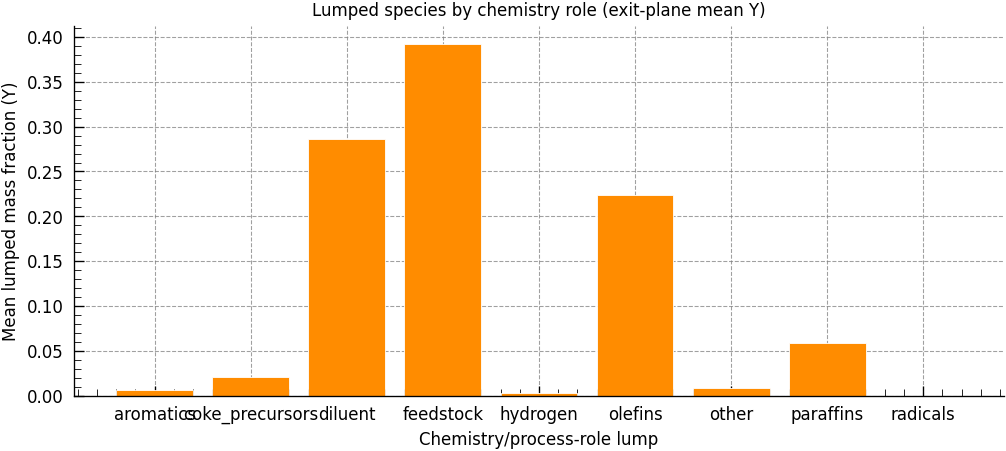

In [9]:
def _extract_carbon_count(species_name: str) -> int | None:
    """Extract carbon count from species name (e.g., 'Y_C2H4(8)' -> 2).
    
    Returns None for inert/non-hydrocarbon species (H2, Water, Ar, He, Ne, N2, H).
    """
    name = species_name[2:] if species_name.startswith(('Y_', 'X_')) else species_name
    name_base = name.split('(')[0]
    # Inert / non-hydrocarbon species stay in their own category
    inert_species = {'Water', 'Ar', 'He', 'Ne', 'N2', 'H2', 'H', 'S'}
    if name_base in inert_species:
        return None
    special_map = {'Benzene': 6, 'Toluene': 7, 'Styrene': 8}
    if name_base in special_map:
        return special_map[name_base]
    match = re.match(r'^C(\d+)H', name_base)
    if match:
        return int(match.group(1))
    if name_base.startswith('CH'):
        return 1
    if name_base in ('CC', 'CCC') or name_base.startswith('C#C'):
        return name_base.count('C')
    return None


def _classify_species_chemistry(species_name: str) -> str:
    """Classify species by chemical/process role in steam cracking.
    
    Categories:
      - olefins: primary light olefin products (ethylene, propylene, butadiene, butenes)
      - aromatics: BTX and styrene (valuable products)
      - paraffins: light saturated hydrocarbons (methane, ethane, propane)
      - coke_precursors: acetylenes, dienes, heavy unsaturates that promote coking
      - radicals: reactive intermediates (CH3, C2H3, C2H5, etc.)
      - feedstock: unreacted feed (n-hexane)
      - hydrogen: H2 (separate due to its unique role in cracking)
      - diluent: steam, inert gases
      - other: unclassified species
    """
    name = species_name[2:] if species_name.startswith(('Y_', 'X_')) else species_name
    name_base = name.split('(')[0]
    
    # Hydrogen (separate category due to its unique role)
    if name_base == 'H2':
        return 'hydrogen'
    
    # Diluent / inert
    if name_base in {'Water', 'Ar', 'He', 'Ne', 'N2', 'H'}:
        return 'diluent'
    
    # Feedstock (n-hexane)
    if name_base == 'C6H14':
        return 'feedstock'
    
    # Primary olefins (main products)
    if name_base in {'C2H4', 'C3H6', 'C4H6', 'C4H8'}:  # ethylene, propylene, butadiene, butenes
        return 'olefins'
    
    # BTX aromatics (valuable)
    if name_base in {'Benzene', 'Toluene', 'Styrene', 'C8H10'}:
        return 'aromatics'
    
    # Light paraffins
    if name_base in {'CH4', 'CC', 'CCC'}:  # methane, ethane, propane
        return 'paraffins'
    
    # Coke precursors: acetylenes, alkynes, cyclopentadienes, heavy dienes
    if name_base.startswith('C#C') or name_base == 'C2H2':  # acetylenes/alkynes
        return 'coke_precursors'
    if name_base in {'C5H6', 'C5H5', 'C6H6', 'C6H8'}:  # cyclopentadiene, CPD radical, other C6 dienes
        return 'coke_precursors'
    if name_base == 'C3H4':  # propyne/allene
        return 'coke_precursors'
    if name_base in {'C4H4', 'C4H5'}:  # vinylacetylene, butenynyl
        return 'coke_precursors'
    # C7+ unsaturates are also coke precursors
    match = re.match(r'^C(\d+)H(\d+)', name_base)
    if match:
        c_count = int(match.group(1))
        h_count = int(match.group(2))
        # Highly unsaturated (H/C < 1.5) and C>=6 -> coke precursors
        if c_count >= 6 and h_count / c_count < 1.5:
            return 'coke_precursors'
    
    # Radicals (odd H count typically, or known radical patterns)
    radical_patterns = {'CH3', 'C2H3', 'C2H5', 'C3H5', 'C3H7', 'C4H7', 'C4H9', 
                        'C5H7', 'C5H9', 'C5H11', 'C6H7', 'C6H9', 'C6H11', 'C6H13',
                        'C7H9', 'C7H11', 'C3H3'}
    if name_base in radical_patterns:
        return 'radicals'
    # S species (sulfur)
    if name_base == 'S':
        return 'other'
    
    return 'other'

def _sum_columns_streaming(df_full: pd.DataFrame, cols: list[str]) -> np.ndarray:
    """Memory-efficient row-wise sum across many columns.

    `df_full[cols].sum(axis=1)` materialises a full (n_cols x n_rows) float64
    copy which can blow up RAM (e.g. 71 species x 9.2M rows -> ~5 GB). Here we
    accumulate one column at a time into a single float32 buffer, so peak
    extra memory is ~one column.
    """
    out = np.zeros(len(df_full), dtype=np.float32)
    for c in cols:
        out += df_full[c].to_numpy(dtype=np.float32, copy=False)
    return out


def _build_lumped_species_columns(df_full: pd.DataFrame, data_categories: dict, mode: str) -> pd.DataFrame:
    """Sum mass fractions (Y_*) within each lump for ML export (mole fractions excluded)."""
    lump: dict[str, np.ndarray] = {}
    if mode == 'lumped_chemistry':
        for key, cols in data_categories.items():
            if key.startswith('species_Y_'):
                role = key[len('species_Y_'):]
                exist = [c for c in cols if c in df_full.columns]
                if exist:
                    lump[f'Y_lump_chem_{role}'] = _sum_columns_streaming(df_full, exist)
    elif mode == 'lumped_carbon':
        for key, cols in data_categories.items():
            if key.startswith('species_mass_fractions_') and key != 'species_mass_fractions':
                suffix = key[len('species_mass_fractions_'):]
                exist = [c for c in cols if c in df_full.columns]
                if exist:
                    lump[f'Y_lump_carbon_{suffix}'] = _sum_columns_streaming(df_full, exist)
    if not lump:
        return pd.DataFrame(index=df_full.index)
    return pd.DataFrame(lump, index=df_full.index, copy=False)


def _merge_lumped_species_into_target(df_target: pd.DataFrame, df_lumps: pd.DataFrame) -> pd.DataFrame:
    drop = [c for c in df_target.columns if c.startswith('Y_')]
    keep = [c for c in df_target.columns if c not in drop]
    out = df_target[keep].copy() if keep else pd.DataFrame(index=df_target.index)
    if len(df_lumps.columns):
        out = pd.concat([out, df_lumps], axis=1)
    return out

# Organize data into logical categories for better analysis and ML
def organize_data_columns(df, separate_by_carbon=False, categorize_by_chemistry=False):
    """Organize dataframe columns into logical categories.
    
    Args:
        df: DataFrame to organize.
        separate_by_carbon: If True, split species by carbon number (C1, C2, ..., inert).
        categorize_by_chemistry: If True, split mass-fraction species by process role 
            (olefins, aromatics, paraffins, coke_precursors, radicals, feedstock, hydrogen, diluent).
    """
    all_cols = df.columns.tolist()
    y_cols = [c for c in all_cols if c.startswith('Y_')]
    
    categories = {
        'inlet_conditions': ['initial_temperature_K', 'initial_pressure_Pa'],
        'reactor_design': ['reactor_length_m', 'reactor_diameter_m'],
        'operating_conditions': ['mass_flow_rate_kgps', 'heat_flux_Wm2'],
        'spatial_coordinates': ['z_position_m', 'relative_position'],
        'state_variables': ['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3'],
        'thermodynamic_properties': [
            'heat_capacity_cp_JkgK', 'heat_capacity_cv_JkgK', 'mean_molecular_weight_kgkmol',
            'enthalpy_Jkg', 'entropy_JkgK', 'internal_energy_Jkg', 'gibbs_free_energy_Jkg',
            'viscosity_Pas', 'thermal_conductivity_WmK'],
        'species_mass_fractions': y_cols,
    }
    
    if separate_by_carbon:
        # Build carbon-grouped categories; inert species (H2, Water, etc.) stay separate
        y_by_c = {}
        for c in y_cols:
            cn = _extract_carbon_count(c)
            if cn is None:
                key = 'species_mass_fractions_inert'
            else:
                key = f'species_mass_fractions_C{cn}'
            y_by_c.setdefault(key, []).append(c)
        categories.update(y_by_c)
    
    if categorize_by_chemistry:
        # Build chemistry/process-role categories (mass fractions only)
        y_by_chem = {}
        for c in y_cols:
            role = _classify_species_chemistry(c)
            key = f'species_Y_{role}'
            y_by_chem.setdefault(key, []).append(c)
        categories.update(y_by_chem)
    
    organized = {}
    for category, cols in categories.items():
        existing = [c for c in cols if c in all_cols]
        if existing:
            organized[category] = existing
    return organized

# Run organization only when we have data
data_categories = {}
df_boundary = df_reactor = df_operating = df_spatial = None
df_state = df_thermo = df_species_Y = df_species_X = df_main = None

#########################################################
# SEPARATE DATA INTO CATEGORIES
#########################################################
if len(df_data) > 0:
    data_categories = organize_data_columns(
        df_data, 
        separate_by_carbon=IF_SEPARATE_SPECIES_BY_CARBON,
        categorize_by_chemistry=IF_CATEGORIZE_BY_CHEMISTRY
    )
    print("=" * 70)
    print("DATA ORGANIZATION AND FEATURES -- TARGETS SETUP")
    print("=" * 70)
    df_boundary = df_data[data_categories['inlet_conditions']] if 'inlet_conditions' in data_categories else None
    df_reactor = df_data[data_categories['reactor_design']] if 'reactor_design' in data_categories else None
    df_operating = df_data[data_categories['operating_conditions']] if 'operating_conditions' in data_categories else None
    df_spatial = df_data[data_categories['spatial_coordinates']] if 'spatial_coordinates' in data_categories else None
    
    df_state = df_data[data_categories['state_variables']] if 'state_variables' in data_categories else None
    df_thermo = df_data[data_categories['thermodynamic_properties']] if 'thermodynamic_properties' in data_categories else None
    df_species_Y = df_data[data_categories['species_mass_fractions']] if 'species_mass_fractions' in data_categories else None
    df_species_X = df_data[data_categories['species_mole_fractions']] if 'species_mole_fractions' in data_categories else None
    
    # Print carbon-based species breakdown if enabled
    if IF_SEPARATE_SPECIES_BY_CARBON:
        print("-" * 70)
        print("SPECIES BY CARBON NUMBER:")
        carbon_keys = sorted([k for k in data_categories if ('_C' in k or '_inert' in k) and 'species_m' in k])
        for key in carbon_keys:
            print(f"  {key}: {len(data_categories[key])} species")
        print("-" * 70)
    
    # Print chemistry-based species breakdown if enabled
    if IF_CATEGORIZE_BY_CHEMISTRY:
        print("-" * 70)
        print("SPECIES BY CHEMISTRY/PROCESS ROLE:")
        chem_keys = sorted([k for k in data_categories if k.startswith('species_Y_')])
        for key in chem_keys:
            print(f"  {key}: {len(data_categories[key])} species")
        print("-" * 70)

    # Visual aid: bar charts of lumped species groups (mass fractions, Y_*)
    df_plot_base = df_exit if ('df_exit' in globals() and isinstance(df_exit, pd.DataFrame) and len(df_exit) > 0) else df_data

    if IF_SEPARATE_SPECIES_BY_CARBON:
        carbon_y_keys = sorted([k for k in data_categories if k.startswith('species_mass_fractions_') and ('_C' in k or k.endswith('_inert'))])
        if carbon_y_keys:
            carbon_vals = {k.replace('species_mass_fractions_', ''): float(df_plot_base[data_categories[k]].sum(axis=1).mean()) for k in carbon_y_keys}
            fig, ax = plt.subplots(figsize=(9, 4))
            setup_matplotlib(ax)
            labels = list(carbon_vals.keys())
            vals = list(carbon_vals.values())
            ax.bar(labels, vals, color='steelblue', edgecolor='white', linewidth=0.5)
            ax.set_ylabel('Mean lumped mass fraction (Y)')
            ax.set_xlabel('Carbon-based lump')
            ax.set_title('Lumped species by carbon number (exit-plane mean Y)')
            ax.tick_params(axis='x', rotation=0)
            plt.tight_layout()
            if IF_SAVE_EDA_PLOTS:
                EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)
                fig.savefig(EDA_FIG_DIR / 'main3_species_lumped_by_carbon_bar_exit.png', dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)

    if IF_CATEGORIZE_BY_CHEMISTRY:
        chem_y_keys = sorted([k for k in data_categories if k.startswith('species_Y_')])
        if chem_y_keys:
            chem_vals = {k.replace('species_Y_', ''): float(df_plot_base[data_categories[k]].sum(axis=1).mean()) for k in chem_y_keys}
            fig, ax = plt.subplots(figsize=(10, 4))
            setup_matplotlib(ax)
            labels = list(chem_vals.keys())
            vals = list(chem_vals.values())
            ax.bar(labels, vals, color='darkorange', edgecolor='white', linewidth=0.5)
            ax.set_ylabel('Mean lumped mass fraction (Y)')
            ax.set_xlabel('Chemistry/process-role lump')
            ax.set_title('Lumped species by chemistry role (exit-plane mean Y)')
            ax.tick_params(axis='x', rotation=0)
            plt.tight_layout()
            if IF_SAVE_EDA_PLOTS:
                EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)
                fig.savefig(EDA_FIG_DIR / 'main3_species_lumped_by_chemistry_bar_exit.png', dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)
    #########################################################
    # MAIN INPUT FEATURES
    #########################################################
    # PFR INPUT PARAMETERS SET TO BE USED AS FEATURES 
    # 7 input features + 1 reactant 
    main_input_features = (
        data_categories.get('inlet_conditions', []) +
        data_categories.get('operating_conditions', []) +
        data_categories.get('reactor_design', []) +
        data_categories.get('spatial_coordinates', [])
        )

    main_input_features = [c for c in main_input_features if c in df_data.columns]
    df_features = df_data[main_input_features] if main_input_features else pd.DataFrame()
    print(f'MODEL RAW INPUT FEATURES = {df_features.columns.to_list()}')
    #########################################################
    # MAIN OUTPUT FEATURES
    #########################################################
    # N output features 
    main_output_features = (
        data_categories.get('state_variables', []) +
        data_categories.get('species_mass_fractions', []) +
        data_categories.get('species_mole_fractions', []) +
        data_categories.get('thermodynamic_properties', []))
    main_output_features = [c for c in main_output_features if c in df_data.columns]
    df_target = df_data[main_output_features] if main_output_features else pd.DataFrame()
    export_species_as = EXPORT_SPECIES_AS
    if export_species_as == 'lumped_chemistry' and not IF_CATEGORIZE_BY_CHEMISTRY:
        print('[WARN] EXPORT_SPECIES_AS=lumped_chemistry requires IF_CATEGORIZE_BY_CHEMISTRY=True; keeping individual species.')
        export_species_as = 'individual'
    if export_species_as == 'lumped_carbon' and not IF_SEPARATE_SPECIES_BY_CARBON:
        print('[WARN] EXPORT_SPECIES_AS=lumped_carbon requires IF_SEPARATE_SPECIES_BY_CARBON=True; keeping individual species.')
        export_species_as = 'individual'
    if export_species_as in ('lumped_chemistry', 'lumped_carbon'):
        df_lumps = _build_lumped_species_columns(df_data, data_categories, export_species_as)
        if df_lumps.shape[1] == 0:
            print('[WARN] No lumped species columns built; keeping individual Y_* in df_target.')
        else:
            df_target = _merge_lumped_species_into_target(df_target, df_lumps)
            print(f'EXPORT_SPECIES_AS={export_species_as}: replaced individual species with {df_lumps.shape[1]} lumped columns.')
    print(f'MODEL RAW OUTPUT TARGETS = {df_target.columns.to_list()}')
else:
    print("No data to organize. Load data in the previous cell.")

### 3b. Run ID & Residence Time

Assign an integer `run_id` to each unique combination of inlet boundary conditions (BC columns).
This is used for run-level train/test splits in Main_5, Main_6, Main_7.

Also compute `residence_time_s` (τ) by trapezoidal integration of dz/u along each axial profile.
τ is the key independent variable for PINN physics terms and symbolic regression (Main_8).

In [ ]:
# ── Run ID & Residence Time ───────────────────────────────────────────────
def _assign_run_id(df, bc_cols=BC_COLS):
    present = [c for c in bc_cols if c in df.columns]
    unique_bcs = df[present].drop_duplicates().reset_index(drop=True)
    unique_bcs['run_id'] = np.arange(len(unique_bcs), dtype=np.int32)
    return df.merge(unique_bcs, on=present, how='left')['run_id']

def _compute_residence_time(
    df, z_col='z_position_m', vel_col='velocity_ms', bc_cols=BC_COLS
):
    """Trapezoid integration of dz/u per run → residence_time_s."""
    present = [c for c in bc_cols if c in df.columns]
    if z_col not in df.columns or vel_col not in df.columns:
        print('[tau] z_position_m or velocity_ms missing — setting tau=0.')
        return np.zeros(len(df))
    run_key = df[present].apply(tuple, axis=1) if present else pd.Series(0, index=df.index)
    tau = np.zeros(len(df), dtype=np.float64)
    for _, grp in df.groupby(run_key, sort=False):
        idx_loc = grp.index
        grp_s = grp.sort_values(z_col)
        z = grp_s[z_col].values
        u = np.where(grp_s[vel_col].values > 0, grp_s[vel_col].values, np.nan)
        dz = np.diff(z, prepend=z[0])
        dt = dz / u
        dt[0] = 0.0
        cum_tau = np.nancumsum(dt)
        # write back in original (unsorted) order
        orig_order = grp_s.index.get_indexer(idx_loc)
        tau[df.index.get_indexer(idx_loc)] = cum_tau[orig_order]
    return tau

if len(df_data) > 0:
    df_data = df_data.copy()
    df_data['run_id'] = _assign_run_id(df_data)
    df_data['residence_time_s'] = _compute_residence_time(df_data)
    n_runs = df_data['run_id'].nunique()
    print(f'run_id assigned: {n_runs} unique runs')
    print(f'residence_time_s range: {df_data["residence_time_s"].min():.4f} — '
          f'{df_data["residence_time_s"].max():.4f} s')

    # Add residence_time_s to features if not already present
    if 'residence_time_s' not in df_features.columns:
        df_features = df_features.copy()
        df_features['residence_time_s'] = df_data['residence_time_s'].values

### 3c. Reaction Rate Proxies (df_rates)

Compute finite-difference reaction rates for each lumped species:

$$R_i \approx \rho \cdot u \cdot \frac{dY_i}{dz}$$

These are saved in the export pickle as `df_rates` and consumed by **Main_8** (PySR symbolic
regression) to learn closed-form rate laws directly — used by Main_8 for symbolic regression.

In [ ]:
# ── Reaction rate proxies (for Main_8 SR) ─────────────────────────────────
def _compute_df_rates(
    df_feat, df_tgt,
    z_col='z_position_m', vel_col='velocity_ms', rho_col='density_kgm3',
    bc_cols=BC_COLS,
):
    """R_i = rho * u * dY_i/dz per run via np.gradient."""
    lump_cols = [c for c in df_tgt.columns if c.startswith('Y_lump')]
    if not lump_cols:
        print('[df_rates] No Y_lump_* columns in df_target — skipping.')
        return pd.DataFrame(index=df_feat.index)

    df_full = pd.concat([df_feat, df_tgt], axis=1).copy()
    present = [c for c in bc_cols if c in df_full.columns]
    run_key = df_full[present].apply(tuple, axis=1) if present else pd.Series(0, index=df_full.index)
    rate_data = {}
    for col in lump_cols:
        rate_col = 'R_' + col.replace('Y_lump_chem_', '').replace('Y_lump_carbon_', '')
        r = np.zeros(len(df_full))
        for _, grp in df_full.groupby(run_key, sort=False):
            grp_s = grp.sort_values(z_col)
            z  = grp_s[z_col].values
            y  = grp_s[col].values
            u  = grp_s[vel_col].values if vel_col in grp_s.columns else np.ones(len(grp_s))
            rho = grp_s[rho_col].values if rho_col in grp_s.columns else np.ones(len(grp_s))
            dydz = np.gradient(y, z)
            r_run = rho * u * dydz
            r[df_full.index.get_indexer(grp_s.index)] = r_run
        rate_data[rate_col] = r
    return pd.DataFrame(rate_data, index=df_feat.index)

df_rates = pd.DataFrame()
if IF_COMPUTE_RATES and len(df_data) > 0 and df_features is not None and df_target is not None:
    df_rates = _compute_df_rates(df_features, df_target)
    if not df_rates.empty:
        print(f'df_rates: {df_rates.shape} — columns: {df_rates.columns.tolist()}')
        print(df_rates.describe().round(6))
    else:
        print('[df_rates] Empty — check that EXPORT_SPECIES_AS=lumped_chemistry.')
else:
    print('df_rates skipped (IF_COMPUTE_RATES=False or no data).')

## 4. Export features & targets

If IF_EXPORT_FEATURES_TARGETS is True, saves `df_features` and `df_target` to EXPORT_DIR as a single pickle.

EXPORT_SPECIES_AS (config cell): `individual` keeps every `Y_*` mass-fraction column in `df_target` (mole fractions `X_*` are not ML targets). `lumped_chemistry` or `lumped_carbon` replaces those `Y_*` columns with summed `Y_lump_*` lumps. Requires the matching lumping flag (`IF_CATEGORIZE_BY_CHEMISTRY` or `IF_SEPARATE_SPECIES_BY_CARBON`).

In [ ]:
if IF_EXPORT_FEATURES_TARGETS and df_features is not None and df_target is not None:
    os.makedirs(EXPORT_DIR, exist_ok=True)
    export_path = os.path.join(EXPORT_DIR, EXPORT_FEATURES_TARGETS_FILE_NAME)

    # Build export payload
    payload = {
        'df_features': df_features,
        'df_target':   df_target,
        'feature_cols': df_features.columns.tolist(),
        'target_cols':  df_target.columns.tolist(),
        'lump_mode':    EXPORT_SPECIES_AS,
    }
    if not df_rates.empty:
        payload['df_rates'] = df_rates
        payload['rate_cols'] = df_rates.columns.tolist()

    save_pickle_portable(payload, export_path)

    # Manifest JSON (reproducibility + downstream loader)
    n_runs_export = int(df_features.merge(
        df_features[[c for c in BC_COLS if c in df_features.columns]].drop_duplicates(),
        how='left'
    ).shape[0] // max(1, len(df_features) // max(1, df_features[[c for c in BC_COLS if c in df_features.columns]].drop_duplicates().shape[0])))
    n_unique_runs = df_features[[c for c in BC_COLS if c in df_features.columns]].drop_duplicates().shape[0] if any(c in df_features.columns for c in BC_COLS) else 0
    manifest = {
        'export_pkl':        export_path,
        'created_at':        datetime.datetime.now().isoformat(timespec='seconds'),
        'source_data_file':  CORE_DATA_FILE_NAME,
        'n_rows':            int(len(df_features)),
        'n_unique_runs':     n_unique_runs,
        'export_species_as': EXPORT_SPECIES_AS,
        'bc_cols':           [c for c in BC_COLS if c in df_features.columns],
        'feature_cols':      df_features.columns.tolist(),
        'target_cols':       df_target.columns.tolist(),
        'rates_enabled':     not df_rates.empty,
        'rate_cols':         df_rates.columns.tolist() if not df_rates.empty else [],
        'velocity_qc':       qc_meta,
    }
    manifest_path = export_path.replace('.pkl', '_manifest.json')
    with open(manifest_path, 'w') as f:
        json.dump(manifest, f, indent=2)

    print(50*'=')
    print(f'EXPORT -> {export_path}')
    print(f'MANIFEST -> {manifest_path}')
    print(f'  rows: {len(df_features):,} | runs: {n_unique_runs} | '
          f'features: {len(df_features.columns)} | targets: {len(df_target.columns)}')
    if not df_rates.empty:
        print(f'  rates: {len(df_rates.columns)} columns')
    print(50*'=')
elif IF_EXPORT_FEATURES_TARGETS:
    print(50*'=')
    print('EXPORT SKIPPED — df_features or df_target is None')
    print(50*'=')
else:
    print(50*'=')
    print('EXPORT DISABLED (IF_EXPORT_FEATURES_TARGETS=False).')
    print(50*'=')